<a href="https://colab.research.google.com/github/gocleanwater/AI-class/blob/main/week12/MNIST_script_number_CNN_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 오늘 할 내용
MNIST 필기체 숫자 인식을 **Fully Connected Network(Dense)** 에서 Flatten으로 하지 않고(교재 pp. 129-133),

이번에는 **CNN(Convolution Neural Network)** 을 이용하여 해보자!!

# 0. 데이터 전처리

In [28]:
import tensorflow as tf
import matplotlib.pyplot as plt


(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

print(train_images.shape)
print(test_images.shape)

(60000, 28, 28)
(10000, 28, 28)


출력이 다음과 같이 나온다.
```Bash
(데이터 개수, 세로, 가로)
```
그래서 위의 출력은
```Bash
(60000, 28, 28)
(10000, 28, 28)
```
다음과 같이 나오고, 해당 shape의 의미는
```text
train_images는 60,000개의 28×28 크기의 이미지가 있다.
test_images는 10,000개의 28×28 크기의 이미지가 있다.
```
MNIST는 흑백 이미지이기 때문에, 채널(RGB 등등)이 어처피 1이므로 채널이 없다.

---

## 0-1. CNN에 맞게 reshape

**근데, CNN은 입력을 다음과 같이 받는다.**
```Bash
(데이터 개수, 세로, 가로, 채널)
```
즉, 위의 shape에서 채널을 하나 더 추가해줘야 한다. MNIST는 흑백이니까 채널 수가 `1`이므로 다음과 같은 shape가 되도록 reshape를 진행한다.
```Bash
(60000, 28, 28, 1)
(10000, 28, 28, 1)
```

---

In [29]:
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

## 0-2. 픽셀 값 정규화

MNIST의 픽셀값은 원래 `0 ~ 255` 사이이다.
```text
0   → 검정
255 → 흰색
```
딥러닝 모델은 보통 작은 숫자 범위에서 더 안정적으로 학습되기 때문에 `0 ~ 1` 사이로 바꿔준다. (교재 pp. 322-323)

In [30]:
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# 1. CNN 모델 만들기

In [31]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

## 1-1. 교재의 모델의 구조
교재의 모델 구조는 다음과 같다.
```text
Conv2D        → 이미지 특징 추출 (input_shape=(28, 28, 1))
MaxPooling2D  → 크기 줄이면서 중요한 특징 유지
Conv2D        → 더 복잡한 특징 추출
MaxPooling2D  → 다시 크기 축소
Conv2D        → 출력 직전 더 복잡(특수)한 특징 추출
Flatten       → 2차원 특징맵을 1차원 벡터로 변환
Dense         → 분류
Dense(10)     → 0~9 숫자 중 하나로 분류
```

## 1-2. 코드 분석
### 1-2-1. Conv2D Layer
```python
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
```
위의 코드는 CNN에서 합성곱 층(Convolution Layer) 을 하나 추가하는 코드이다.

해당 코드의 **입력 파라미터**를 순서대로 보면,

> - 필터의 개수(교재에는 커널 개수): `32`
> - 필터의 크기: `(3, 3)` → 3 × 3 크기의 윈도우
> - 활성화 함수: `activation="relu"` → 활성화 함수로 relu 함수를 사용

와 같다.

즉, 전체 의미는 이렇게 요약된다.
> **입력 이미지에서 3x3 크기의 필터 32개를 사용해서 특징을 추출하고,그 결과에 ReLU 활성화 함수를 적용한다.**

---

### 1-2-2. MaxPooling2D Layer
```python
    tf.keras.layers.MaxPooling2D((2, 2)),
```

위의 코드는 CNN에서 Max Pooling 층을 추가하는 코드이다.

해당 코드의 **입력 파라미터**를 순서대로 보면,

> - Pooling 할 윈도우(영역)의 크기: `(2, 2)` → 2 × 2 크기의 영역에서 Max Pooling을 실시

즉, 전체 의미는 이렇게 요약된다.
> **2x2 영역에서 가장 큰 값만 남겨서 특징맵의 크기를 줄이고, 중요한 특징을 유지시킨다.**

---

## 1-3. 출력 shape

입력 shape가 `(28, 28, 1)`이므로 여기에 `f.keras.layers.MaxPooling2D((2, 2))`를 적용하면,

기본 Padding이 `"valid"`이므로, 가장자리까지 유지하지 않고, 3x3 필터가 완전히 들어갈 수 있는 위치만 계산하기 때문에 다음과 같이 나온다.
```text
28 x 28
→ 3 x 3 필터 적용
→ 26 x 26
```
그리고 필터가 32개니까 마지막 차원이 32가 된다.

최종 shape: `(높이, 너비, 필터 개수)` (교재 p.377에서는 필터가 아닌 커널의 개수라고 함)
```text
(26, 26, 32)
```

해당 결과`(26, 26, 32)`에 `tf.keras.layers.MaxPooling2D((2, 2))`를 적용하면,

실제 `tf.keras.layers.MaxPooling2D`는 다음과 같이 매개변수를 받으므로,
```python
tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=None,
    padding="valid",
)
```
여기서 strides=None이면 기본적으로 strides=(2, 2)처럼 동작학 때문에, 2×2 영역을 보고 2칸씩 이동한다. 그래서 높이와 너비의 크기가 절반으로 줄어든다.

최종 shape:
```text
(13, 13, 32)
```
> **전체 과정:**
> ```text
> 입력 이미지
> (28, 28, 1)
>
> Conv2D(32, 3x3)
> → (26, 26, 32)
>
> MaxPooling2D(2x2)
> → (13, 13, 32)
> ```

---

# 2. 컴파일

In [32]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

MNIST 라벨은 보통 다음과 같이 되어 있기 때문에,
```python
train_labels = [5, 0, 4, 1, ...]
```
즉, 원-핫 인코딩이 아니라 그냥 숫자 라벨이므로, 원-핫 인코딩을 해야 하지만, 그것을 지원해주는 `sparse_categorical_crossentropy`를 이용한다. (교재 p. 313)

---

# 3. 학습

In [33]:
# 과잉적합을 막기 위한 코드라고 함.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

# 이건 이번에 챗지피티한테 물어보니까 Optimizer(경사하강법)의 학습률을 줄이는 용도라고 한다!!!
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping, reduce_lr],
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.9401 - loss: 0.1994 - val_accuracy: 0.9810 - val_loss: 0.0627 - learning_rate: 0.0010
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9835 - loss: 0.0528 - val_accuracy: 0.9897 - val_loss: 0.0358 - learning_rate: 0.0010
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9882 - loss: 0.0379 - val_accuracy: 0.9830 - val_loss: 0.0567 - learning_rate: 0.0010
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 57ms/step - accuracy: 0.9902 - loss: 0.0299 - val_accuracy: 0.9873 - val_loss: 0.0421 - learning_rate: 0.0010
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9926 - loss: 0.0236 - val_accuracy: 0.9895 - val_loss: 0.0370 - learning_rate: 0.0010
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - accuracy: 0.9940 - loss: 0.0196 - val_accuracy: 0.9932 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 54ms/step - accuracy: 0.9948 - l

# 4. 테스트 평가

In [34]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9920 - loss: 0.0278
Test accuracy: 0.9919999837875366


## 4-1. 시각화

In [35]:
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(loss) + 1)

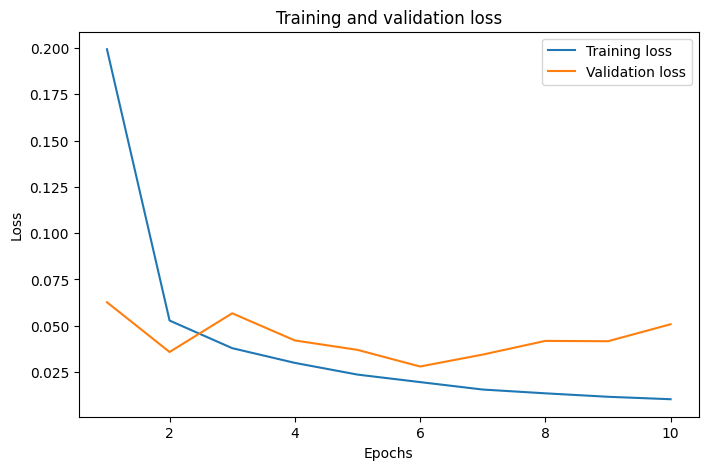

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()